==========================================
ANALISIS EXPLORATORIO DE DATOS CON PANDAS
Dataset: WorldCupPlayers.csv
==========================================
Autor: Gabriel Nicolas Euan Perez

Materia: Analítica de Datos

Objetivo:
Aplicar técnicas de análisis, limpieza,
transformación y exploración de datos.

In [1]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv("WorldCupPlayers.csv")

print("Dataset cargado correctamente")

Dataset cargado correctamente


In [3]:
df.head()

,RoundID,MatchID,Team Initials,Coach Name,Line-up,Shirt Number,Player Name,Position,Event
0,201,1096,FRA,CAUDRON Raoul (FRA),S,0,Alex THEPOT,GK,NaN
1,201,1096,MEX,LUQUE Juan (MEX),S,0,Oscar BONFIGLIO,GK,NaN
2,201,1096,FRA,CAUDRON Raoul (FRA),S,0,Marcel LANGILLER,NaN,G40'
3,201,1096,MEX,LUQUE Juan (MEX),S,0,Juan CARRENO,NaN,G70'
4,201,1096,FRA,CAUDRON Raoul (FRA),S,0,Ernest LIBERATI,NaN,NaN


In [4]:
df.tail()

,RoundID,MatchID,Team Initials,Coach Name,Line-up,Shirt Number,Player Name,Position,Event
37779,255959,300186501,ARG,SABELLA Alejandro (ARG),N,19,ALVAREZ,NaN,NaN
37780,255959,300186501,GER,LOEW Joachim (GER),N,6,KHEDIRA,NaN,NaN
37781,255959,300186501,ARG,SABELLA Alejandro (ARG),N,20,AGUERO,NaN,IH46' Y65'
37782,255959,300186501,GER,LOEW Joachim (GER),N,21,MUSTAFI,NaN,NaN
37783,255959,300186501,ARG,SABELLA Alejandro (ARG),N,23,BASANTA,NaN,NaN


In [5]:
print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

Filas: 37784
Columnas: 9


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 37784 entries, 0 to 37783
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   RoundID        37784 non-null  int64
 1   MatchID        37784 non-null  int64
 2   Team Initials  37784 non-null  str  
 3   Coach Name     37784 non-null  str  
 4   Line-up        37784 non-null  str  
 5   Shirt Number   37784 non-null  int64
 6   Player Name    37784 non-null  str  
 7   Position       4143 non-null   str  
 8   Event          9069 non-null   str  
dtypes: int64(3), str(6)
memory usage: 2.6 MB


In [7]:
df.dtypes

RoundID          int64
MatchID          int64
Team Initials      str
Coach Name         str
Line-up            str
Shirt Number     int64
Player Name        str
Position           str
Event              str
dtype: object

In [8]:
df.describe()

,RoundID,MatchID,Shirt Number
count,3.778400e+04,3.778400e+04,37784.000000
mean,1.105647e+07,6.362233e+07,10.726022
std,2.770144e+07,1.123916e+08,6.960138
min,2.010000e+02,2.500000e+01,0.000000
25%,2.630000e+02,1.199000e+03,5.000000
50%,3.370000e+02,2.216000e+03,11.000000
75%,2.559310e+05,9.741000e+07,17.000000
max,9.741060e+07,3.001865e+08,23.000000


In [9]:
df.isnull().sum()

RoundID              0
MatchID              0
Team Initials        0
Coach Name           0
Line-up              0
Shirt Number         0
Player Name          0
Position         33641
Event            28715
dtype: int64

In [10]:
(df.isnull().sum() / len(df)) * 100

RoundID           0.000000
MatchID           0.000000
Team Initials     0.000000
Coach Name        0.000000
Line-up           0.000000
Shirt Number      0.000000
Player Name       0.000000
Position         89.035041
Event            75.997777
dtype: float64

In [11]:
df.duplicated().sum()

np.int64(736)

In [12]:
df = df.drop_duplicates()

print("Duplicados eliminados")

Duplicados eliminados


In [13]:
columnas_numericas = df.select_dtypes(include=np.number).columns

columnas_numericas

Index(['RoundID', 'MatchID', 'Shirt Number'], dtype='str')

In [14]:
for columna in columnas_numericas:
    df[columna] = df[columna].fillna(df[columna].mean())

print("Valores numéricos corregidos")

Valores numéricos corregidos


In [15]:
columnas_categoricas = df.select_dtypes(include='object').columns

columnas_categoricas

C:\Users\Gaby\AppData\Local\Temp\ipykernel_12544\758409947.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columnas_categoricas = df.select_dtypes(include='object').columns


Index(['Team Initials', 'Coach Name', 'Line-up', 'Player Name', 'Position',
       'Event'],
      dtype='str')

In [16]:
for columna in columnas_categoricas:
    moda = df[columna].mode()[0]
    df[columna] = df[columna].fillna(moda)

print("Valores categóricos corregidos")

Valores categóricos corregidos


In [17]:
df["Team Initials"].value_counts()

Team Initials
BRA    2311
ITA    1843
ARG    1715
ENG    1378
FRG    1364
       ... 
IRQ      66
UAE      66
JAM      66
CUB      45
INH      18
Name: count, Length: 82, dtype: int64

In [18]:
df["Coach Name"].value_counts()

Coach Name
SCHOEN Helmut (FRG)               550
PARREIRA Carlos Alberto (BRA)     514
SCOLARI Luiz Felipe (BRA)         483
MILUTINOVIC Bora (YUG)            443
ZAGALLO Mario (BRA)               440
                                 ... 
PASCUCCI Felipe (ITA)              18
VAN MASTENBROEK Johannes (NED)     18
McREA James (SCO)                  17
LUIZ VINHAES (BRA)                 17
RADULESCU Constantin (ROU)         15
Name: count, Length: 335, dtype: int64

In [19]:
df["Position"].value_counts()

Position
GK     35378
C       1481
GKC      189
Name: count, dtype: int64

In [20]:
df["Player Name"].value_counts()

Player Name
RONALDO             33
KLOSE               28
CAFU                26
DIDA                25
Sepp MAIER          25
                    ..
Paul EVANS           1
Hussein SULIMANI     1
Omar AL GHAMDI       1
Mourad MELKI         1
ABOU TARIKA          1
Name: count, Length: 7663, dtype: int64

### Transformacion de datos

In [21]:
df["Grupo_Posicion"] = df["Position"].map({
    "GK": "Portero",
    "C": "Capitán",
    "D": "Defensa"
}).fillna("Jugador de Campo")

df[["Player Name","Position","Grupo_Posicion"]].head()

,Player Name,Position,Grupo_Posicion
0,Alex THEPOT,GK,Portero
1,Oscar BONFIGLIO,GK,Portero
2,Marcel LANGILLER,GK,Portero
3,Juan CARRENO,GK,Portero
4,Ernest LIBERATI,GK,Portero


### Mapeo de posiciones

In [22]:
df["Grupo_LineUp"] = df["Line-up"].map({
    "S": "Titular",
    "N": "Suplente"
})

df[["Player Name","Line-up","Grupo_LineUp"]].head()

,Player Name,Line-up,Grupo_LineUp
0,Alex THEPOT,S,Titular
1,Oscar BONFIGLIO,S,Titular
2,Marcel LANGILLER,S,Titular
3,Juan CARRENO,S,Titular
4,Ernest LIBERATI,S,Titular


### Analisis de relaciones

In [23]:
df["Shirt Number"].mean()

np.float64(10.700712589073634)

In [24]:
df["MatchID"].mean()

np.float64(58922717.74473656)

In [25]:
df.groupby("Team Initials")["Shirt Number"].mean()

Team Initials
ALG    11.774744
ANG    12.000000
ARG    10.745190
AUS    11.888514
AUT     9.913793
         ...    
URU     9.886444
USA     9.838527
WAL    11.500000
YUG     9.816020
ZAI    11.500000
Name: Shirt Number, Length: 82, dtype: float64

In [26]:
df.groupby("Team Initials")["Position"].value_counts()

Team Initials  Position
ALG            GK           280
               C             13
ANG            GK            66
               C              3
ARG            GK          1638
                           ... 
WAL            C              5
YUG            GK           762
               C             37
ZAI            GK            63
               C              3
Name: count, Length: 202, dtype: int64

In [27]:
df.groupby("Position")["Shirt Number"].mean()

Position
C       7.089804
GK     10.899938
GKC     1.703704
Name: Shirt Number, dtype: float64

In [28]:
Q1 = df["Shirt Number"].quantile(0.25)
Q3 = df["Shirt Number"].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print("Límite inferior:", limite_inferior)
print("Límite superior:", limite_superior)

Límite inferior: -13.0
Límite superior: 35.0


In [29]:
outliers = df[
    (df["Shirt Number"] < limite_inferior) |
    (df["Shirt Number"] > limite_superior)
]

outliers

,RoundID,MatchID,Team Initials,Coach Name,Line-up,Shirt Number,Player Name,Position,Event,Grupo_Posicion,Grupo_LineUp


In [30]:
print("Outliers encontrados:", len(outliers))

Outliers encontrados: 0


In [31]:
df.to_csv(
    "World_Cup_Data_Limpio.csv",
    index=False
)

print("Archivo exportado correctamente")

Archivo exportado correctamente


In [32]:
print("""
CONCLUSIONES

1. Se importó correctamente el conjunto de datos.
2. Se identificaron valores nulos y duplicados.
3. Se aplicaron técnicas de limpieza de datos.
4. Se generaron nuevas variables mediante transformación.
5. Se analizaron relaciones entre consumo de café,
   calidad del sueño y nivel de estrés.
6. Se identificaron valores atípicos utilizando IQR.
7. Se generó un nuevo dataset limpio para futuros análisis.
""")


CONCLUSIONES

1. Se importó correctamente el conjunto de datos.
2. Se identificaron valores nulos y duplicados.
3. Se aplicaron técnicas de limpieza de datos.
4. Se generaron nuevas variables mediante transformación.
5. Se analizaron relaciones entre consumo de café,
   calidad del sueño y nivel de estrés.
6. Se identificaron valores atípicos utilizando IQR.
7. Se generó un nuevo dataset limpio para futuros análisis.



In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

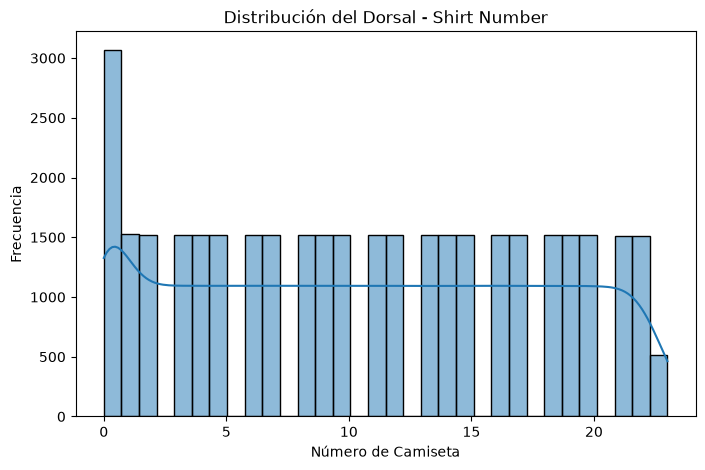

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df["Shirt Number"], kde=True)
plt.title("Distribución del Dorsal - Shirt Number")
plt.xlabel("Número de Camiseta")
plt.ylabel("Frecuencia")
plt.show()

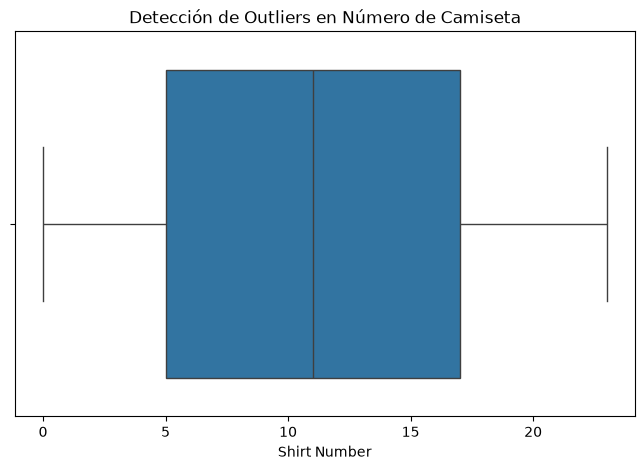

In [35]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Shirt Number"])
plt.title("Detección de Outliers en Número de Camiseta")
plt.show()

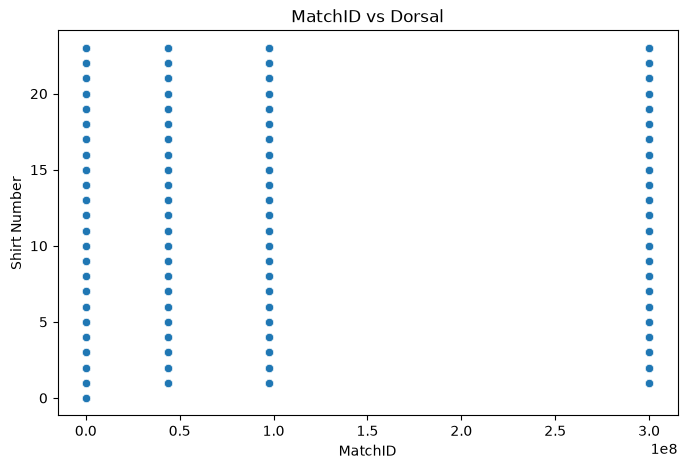

In [36]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x="MatchID",
    y="Shirt Number",
    data=df
)
plt.title("MatchID vs Dorsal")
plt.show()